# Task 02 - Análise Exploratória: contempArt

Este notebook analisa os **441 artistas reais** do recorte `artists.csv` do contempArt.

Objetivos:

- compreender presença digital e disponibilidade de portfólio independente;
- analisar distribuições de seguidores, publicações, imagens, likes e comentários;
- comparar grupos e investigar correlações;
- medir concentração de visibilidade;
- identificar artistas com volume registrado alto e visibilidade baixa;
- agrupar artistas por características digitais semelhantes.

Seguidores e engajamento são sinais digitais e não medidas de talento ou qualidade artística.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)

DATA_PATH = Path("../data/processed/contempart_artists_enriquecido.csv")
df = pd.read_csv(DATA_PATH)

print(f"Registros: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
df.head(3)

Registros: 441
Colunas: 33


,artist_id,full_name,school,east_german,professor_class,gender,country_iso3,continent,region,instagram_handle,instagram_private,instagram_private_allowed,is_business,is_private,follower_count,following_count,posts_count,website,img_count,avg_likes,avg_comments,avg_file_size,avg_width,avg_height,avg_aspect_ratio,possui_instagram,possui_website,somente_instagram_informado,sem_presenca_digital_informada,taxa_engajamento,metricas_engajamento_disponiveis,nivel_visibilidade,quadrante_imagens_visibilidade
0,agneswrobel,Agnes Wrobel,Dresden,True,Macketanz,F,DEU,Europe,Europe & Central Asia,NaN,False,False,NaN,NaN,NaN,NaN,NaN,http://klassemacketanz.de/?p=139/,2,NaN,NaN,1.061378e+06,1031.000000,1314.500000,1.063778,False,True,False,False,NaN,False,NaN,NaN
1,albertgouthier,Albert Gouthier,Dresden,True,Kerbach,M,NaN,NaN,NaN,albertgouthier,False,False,False,False,357.0,589.0,84.0,NaN,64,36.387755,0.959184,4.008307e+05,922.421875,905.750000,1.067207,True,False,True,False,10.461327,True,medio,volume_alto_visibilidade_alta
2,alessiaschuth,Alessia Schuth,Stuttgart,False,Güdemann,F,DEU,Europe,Europe & Central Asia,NaN,False,False,NaN,NaN,NaN,NaN,NaN,http://alessiadaniaschuth.de/,126,NaN,NaN,9.485905e+04,615.341270,797.333333,0.797680,False,True,False,False,NaN,False,NaN,NaN


## 1. Qualidade e disponibilidade dos dados

Antes das análises, é necessário identificar o universo válido de cada métrica. Valores ausentes são preservados e não são substituídos por zero.

In [2]:
colunas_analiticas = [
    "instagram_handle", "website", "follower_count", "following_count",
    "posts_count", "img_count", "avg_likes", "avg_comments",
    "taxa_engajamento", "gender", "country_iso3"
]

qualidade = pd.DataFrame({
    "preenchidos": df[colunas_analiticas].notna().sum(),
    "ausentes": df[colunas_analiticas].isna().sum(),
})
qualidade["percentual_preenchido"] = qualidade["preenchidos"] / len(df) * 100
qualidade.sort_values("percentual_preenchido", ascending=False)

,preenchidos,ausentes,percentual_preenchido
img_count,441,0,100.000000
gender,439,2,99.546485
instagram_handle,366,75,82.993197
posts_count,359,82,81.405896
follower_count,359,82,81.405896
following_count,359,82,81.405896
website,240,201,54.421769
country_iso3,233,208,52.834467
avg_likes,200,241,45.351474
taxa_engajamento,200,241,45.351474


**Interpretação:** seguidores, contas seguidas e publicações possuem 359 registros válidos. Likes, comentários e taxa de engajamento possuem somente 200 registros válidos; qualquer conclusão sobre engajamento deve declarar esse universo reduzido.

## 2. Presença digital e portfólio independente

Perguntas:

- Quantos artistas possuem Instagram?
- Quantos possuem website?
- Quantos dependem somente do Instagram informado?

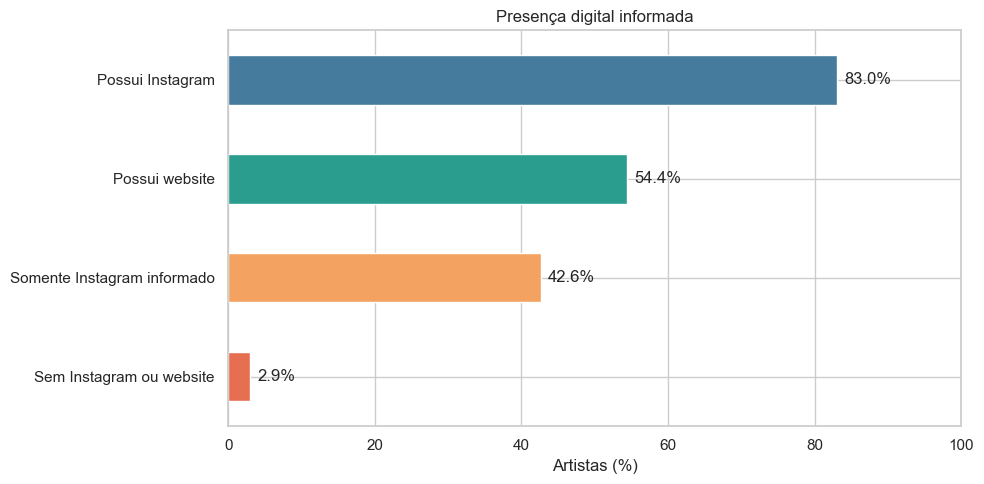

In [3]:
presenca = pd.Series({
    "Possui Instagram": df["possui_instagram"].mean() * 100,
    "Possui website": df["possui_website"].mean() * 100,
    "Somente Instagram informado": df["somente_instagram_informado"].mean() * 100,
    "Sem Instagram ou website": df["sem_presenca_digital_informada"].mean() * 100,
}).sort_values()

ax = presenca.plot.barh(figsize=(10, 5), color=["#E76F51", "#F4A261", "#2A9D8F", "#457B9D"])
ax.set(title="Presença digital informada", xlabel="Artistas (%)", ylabel="")
ax.set_xlim(0, 100)
for i, valor in enumerate(presenca):
    ax.text(valor + 1, i, f"{valor:.1f}%", va="center")
plt.tight_layout()
plt.show()

**Interpretação:** 83,0% possuem Instagram, mas apenas 54,4% possuem website. Além disso, 42,6% apresentam somente Instagram como presença digital identificável. Isso sustenta a utilidade de um portfólio público independente, sem afirmar que todo website ausente representa desorganização.

## 3. Distribuições das métricas digitais

As distribuições são assimétricas e possuem valores extremos. Por isso, os gráficos usam escala logarítmica e as interpretações consideram mediana e percentis.

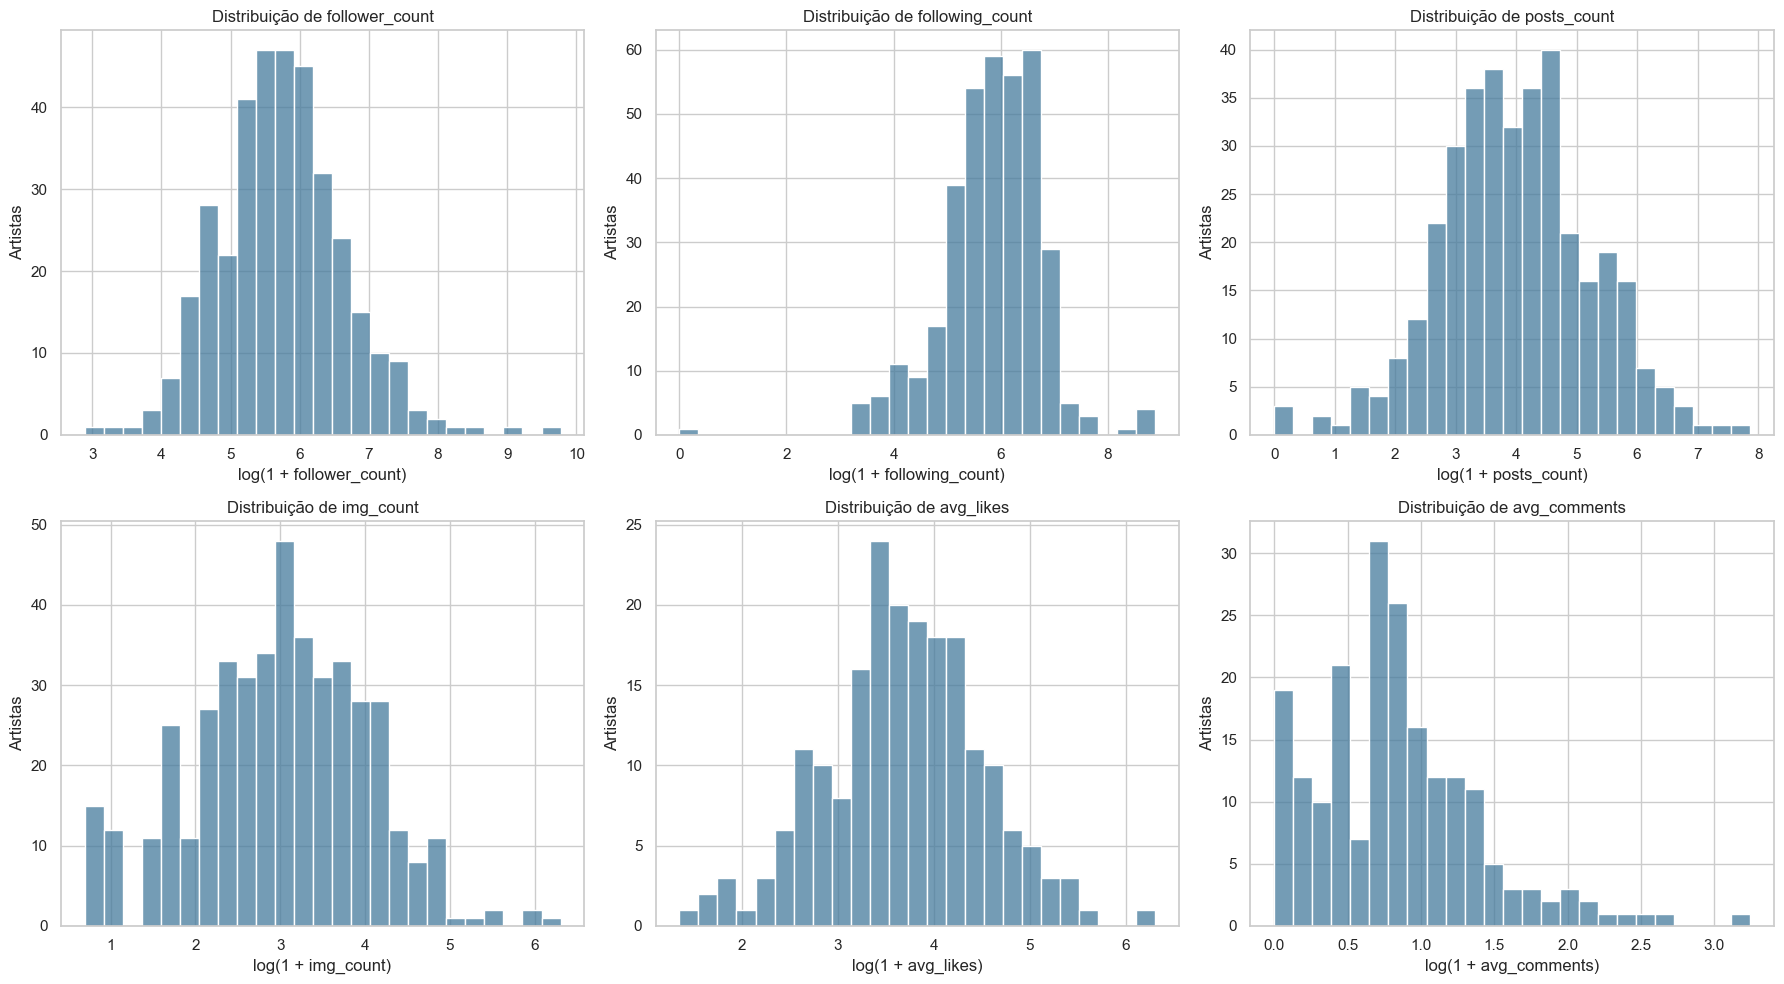

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
follower_count,359.0,521.582173,1131.069148,17.000000,100.000000,176.000000,302.000000,525.000000,1006.200000,1432.300000,3260.260000,17498.000000
following_count,359.0,527.679666,738.140015,0.000000,108.000000,213.000000,387.000000,628.000000,919.000000,1126.300000,4751.400000,7262.000000
posts_count,359.0,114.838440,218.169163,0.000000,12.000000,23.000000,53.000000,111.500000,275.600000,394.000000,815.140000,2613.000000
img_count,441.0,32.648526,47.272001,1.000000,4.000000,10.000000,20.000000,40.000000,66.000000,94.000000,228.600000,545.000000
avg_likes,200.0,54.877204,57.443240,2.857143,13.737799,23.562814,37.731908,68.106157,105.883641,149.788596,236.703269,549.363636
avg_comments,200.0,1.790447,2.494871,0.000000,0.142857,0.549020,1.175926,2.106250,3.321274,6.009184,11.015000,24.636364
taxa_engajamento,200.0,16.304902,10.665167,0.796813,5.149846,9.428938,14.357876,21.642943,29.070209,35.241106,48.831930,86.666667


In [4]:
metricas = ["follower_count", "following_count", "posts_count", "img_count", "avg_likes", "avg_comments"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, coluna in zip(axes.flat, metricas):
    valores = df[coluna].dropna()
    sns.histplot(np.log1p(valores), bins=25, ax=ax, color="#457B9D")
    ax.set(title=f"Distribuição de {coluna}", xlabel=f"log(1 + {coluna})", ylabel="Artistas")

plt.tight_layout()
plt.show()

df[metricas + ["taxa_engajamento"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).T

**Interpretação:** seguidores possuem mediana de 302 e máximo de 17.498; posts possuem mediana de 53 e máximo de 2.613. A diferença entre média e mediana confirma forte assimetria. Comparações devem evitar depender somente da média.

## 4. Comparações entre grupos

Os boxplots comparam distribuições por presença de website e tipo de conta. Eles ajudam a verificar diferenças, mas não demonstram causalidade.

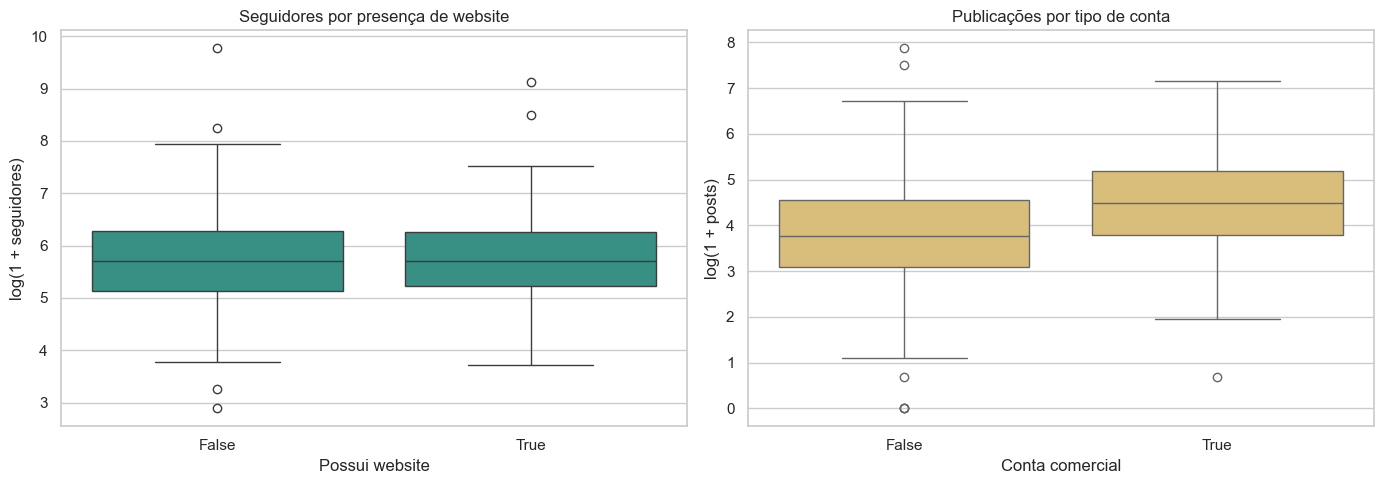

,count,median,mean
possui_website,,,
False,185,302.0,554.4
True,174,301.5,486.7


In [5]:
comparacao = df.dropna(subset=["follower_count", "posts_count"]).copy()
comparacao["log_seguidores"] = np.log1p(comparacao["follower_count"])
comparacao["log_posts"] = np.log1p(comparacao["posts_count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=comparacao, x="possui_website", y="log_seguidores", ax=axes[0], color="#2A9D8F")
axes[0].set(title="Seguidores por presença de website", xlabel="Possui website", ylabel="log(1 + seguidores)")

sns.boxplot(data=comparacao, x="is_business", y="log_posts", ax=axes[1], color="#E9C46A")
axes[1].set(title="Publicações por tipo de conta", xlabel="Conta comercial", ylabel="log(1 + posts)")
plt.tight_layout()
plt.show()

df.groupby("possui_website")["follower_count"].agg(["count", "median", "mean"]).round(1)

**Interpretação:** a mediana de seguidores é praticamente igual entre artistas com e sem website informado. Isso reforça que presença de portfólio independente e popularidade em rede social representam dimensões diferentes.

## 5. Correlações e análise multivariada

É utilizada correlação de Spearman porque as métricas são assimétricas e possuem valores extremos.

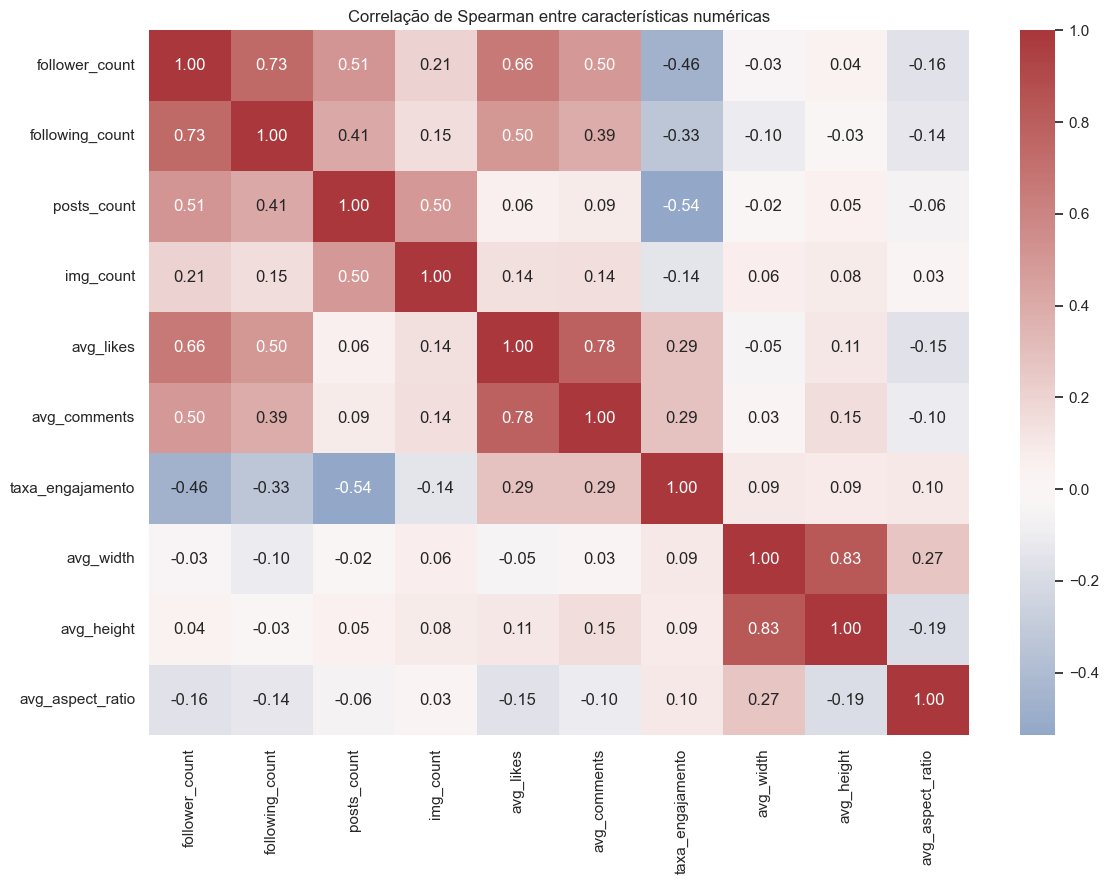

In [6]:
numericas = [
    "follower_count", "following_count", "posts_count", "img_count",
    "avg_likes", "avg_comments", "taxa_engajamento",
    "avg_width", "avg_height", "avg_aspect_ratio"
]
corr = df[numericas].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlação de Spearman entre características numéricas")
plt.tight_layout()
plt.show()

**Interpretação:** seguidores apresentam associação forte com contas seguidas (0,73), moderada com likes (0,66) e posts (0,51), mas fraca com quantidade de imagens do dataset (0,21). A taxa de engajamento apresenta relação negativa com seguidores (-0,46) e posts (-0,54), mostrando que maior escala não significa maior interação relativa.

## 6. Relações entre volume e visibilidade

Scatterplots permitem observar tendência e dispersão. A escala logarítmica reduz o efeito visual de valores extremos.

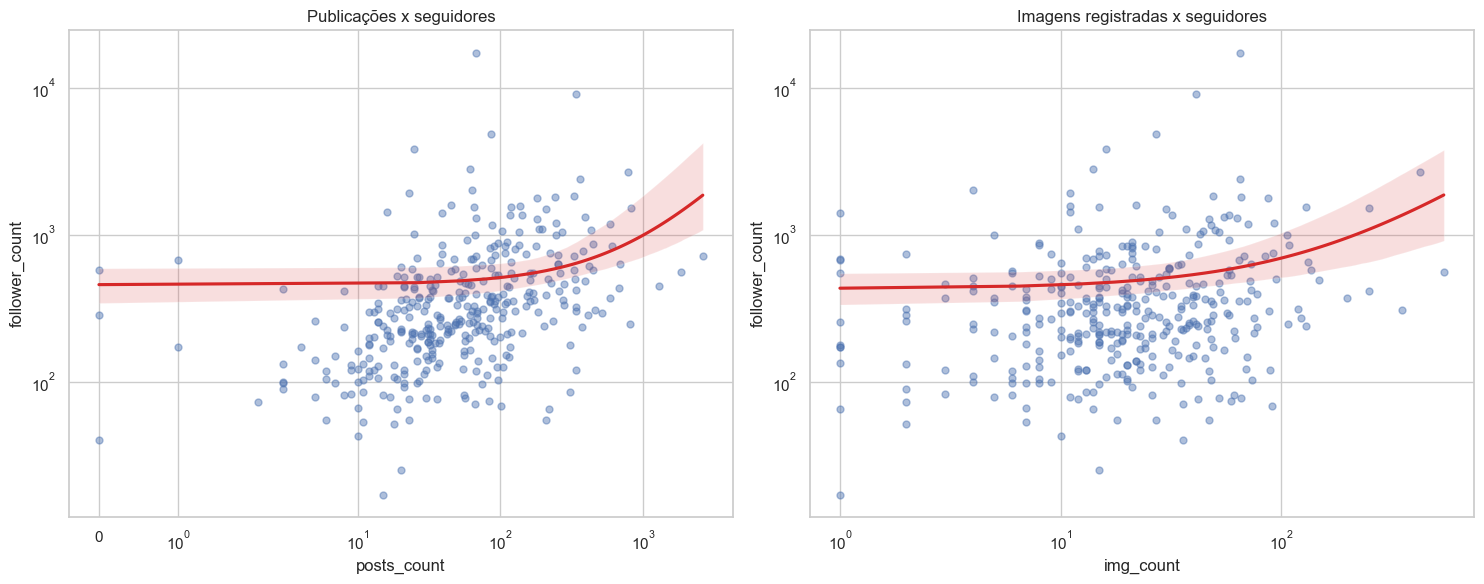

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.regplot(
    data=df, x="posts_count", y="follower_count", ax=axes[0],
    scatter_kws={"alpha": .45, "s": 25}, line_kws={"color": "#D62828"}
)
axes[0].set(xscale="symlog", yscale="log", title="Publicações x seguidores")

sns.regplot(
    data=df, x="img_count", y="follower_count", ax=axes[1],
    scatter_kws={"alpha": .45, "s": 25}, line_kws={"color": "#D62828"}
)
axes[1].set(xscale="log", yscale="log", title="Imagens registradas x seguidores")

plt.tight_layout()
plt.show()

**Interpretação:** existe tendência positiva entre publicações e seguidores, mas a dispersão é ampla. A relação entre imagens registradas e seguidores é mais fraca. Recomendações baseadas somente em quantidade ou popularidade deixariam de representar muitos perfis.

## 7. Quadrantes de volume e visibilidade

O quadrante destaca artistas com `img_count` acima da mediana e seguidores abaixo da mediana. Esse grupo está relacionado à proposta de exposição justa.

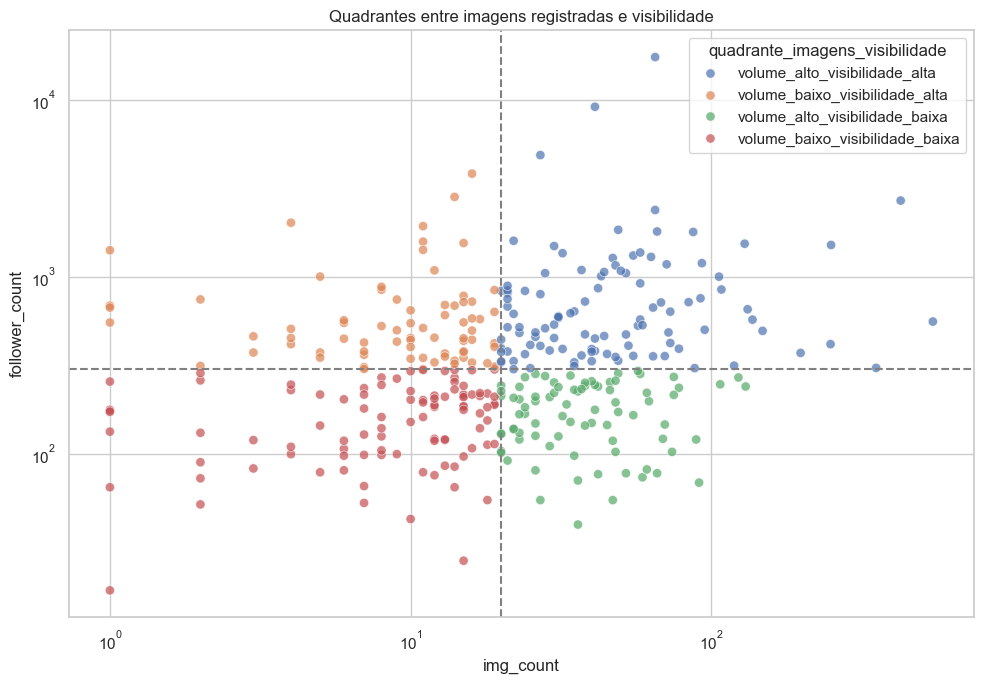

,artistas
quadrante_imagens_visibilidade,
volume_alto_visibilidade_alta,106
volume_baixo_visibilidade_baixa,97
volume_alto_visibilidade_baixa,82
volume_baixo_visibilidade_alta,74


In [8]:
quadrantes = df.dropna(subset=["follower_count", "img_count", "quadrante_imagens_visibilidade"]).copy()
mediana_seguidores = quadrantes["follower_count"].median()
mediana_imagens = quadrantes["img_count"].median()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=quadrantes, x="img_count", y="follower_count",
    hue="quadrante_imagens_visibilidade", alpha=.7, s=45
)
plt.axvline(mediana_imagens, color="gray", linestyle="--")
plt.axhline(mediana_seguidores, color="gray", linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.title("Quadrantes entre imagens registradas e visibilidade")
plt.tight_layout()
plt.show()

quadrantes["quadrante_imagens_visibilidade"].value_counts().to_frame("artistas")

**Interpretação:** existem **82 artistas** no quadrante de volume registrado alto e visibilidade baixa. Esse resultado demonstra um público que poderia se beneficiar de mecanismos de descoberta que não priorizem somente seguidores.

## 8. Concentração de visibilidade

A curva acumulada mostra quanto do total de seguidores está concentrado em uma parcela pequena dos artistas.

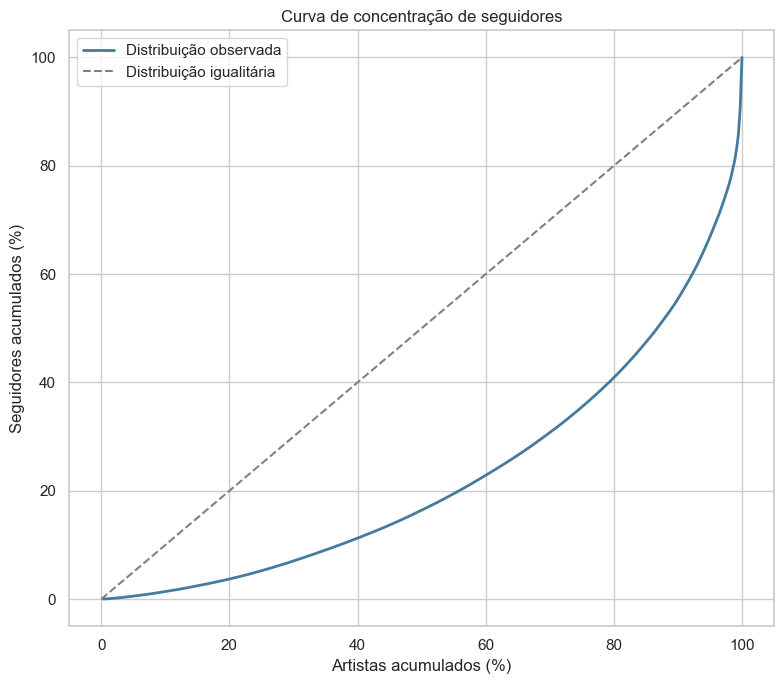

Participação dos 10% maiores    44.6
Participação dos 20% maiores    59.2
dtype: float64

In [9]:
seguidores = df["follower_count"].dropna().sort_values().to_numpy()
participacao_artistas = np.arange(1, len(seguidores) + 1) / len(seguidores) * 100
participacao_seguidores = np.cumsum(seguidores) / seguidores.sum() * 100

plt.figure(figsize=(8, 7))
plt.plot(participacao_artistas, participacao_seguidores, label="Distribuição observada", color="#457B9D", linewidth=2)
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Distribuição igualitária")
plt.xlabel("Artistas acumulados (%)")
plt.ylabel("Seguidores acumulados (%)")
plt.title("Curva de concentração de seguidores")
plt.legend()
plt.tight_layout()
plt.show()

ordenados = df["follower_count"].dropna().sort_values(ascending=False)
concentracao = pd.Series({
    "Participação dos 10% maiores": ordenados.head(int(np.ceil(len(ordenados) * .10))).sum() / ordenados.sum() * 100,
    "Participação dos 20% maiores": ordenados.head(int(np.ceil(len(ordenados) * .20))).sum() / ordenados.sum() * 100,
}).round(1)
concentracao

**Interpretação:** os 10% maiores perfis concentram aproximadamente **44,6%** dos seguidores, e os 20% maiores concentram **59,2%**. A visibilidade é fortemente concentrada, reforçando a necessidade de critérios de descoberta mais equilibrados.

## 9. Agrupamento por características digitais semelhantes

Os grupos são formados sem utilizar `follower_count`, evitando que popularidade defina os clusters. Seguidores são comparados somente depois.

Features utilizadas:

- `posts_count`, `img_count` e `following_count`, com transformação logarítmica;
- presença de website;
- tipo de conta e privacidade;
- características médias das imagens.

In [10]:
features_cluster = [
    "posts_count", "img_count", "following_count", "possui_website",
    "is_business", "is_private", "avg_width", "avg_height", "avg_aspect_ratio"
]

cluster_df = df.dropna(subset=features_cluster).copy()
X = cluster_df[features_cluster].copy()

for coluna in ["posts_count", "img_count", "following_count"]:
    X[coluna] = np.log1p(X[coluna])

X_padronizado = StandardScaler().fit_transform(X)

avaliacao_clusters = []
for k in range(2, 7):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    rotulos = modelo.fit_predict(X_padronizado)
    avaliacao_clusters.append({"k": k, "silhouette": silhouette_score(X_padronizado, rotulos)})

avaliacao_clusters = pd.DataFrame(avaliacao_clusters)
melhor_k = int(avaliacao_clusters.loc[avaliacao_clusters["silhouette"].idxmax(), "k"])

modelo_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=20)
cluster_df["cluster"] = modelo_final.fit_predict(X_padronizado)

pca = PCA(n_components=2, random_state=42)
projecao = pca.fit_transform(X_padronizado)
cluster_df["pca_1"] = projecao[:, 0]
cluster_df["pca_2"] = projecao[:, 1]

avaliacao_clusters

,k,silhouette
0,2,0.351745
1,3,0.182260
2,4,0.254530
3,5,0.190791
4,6,0.222481


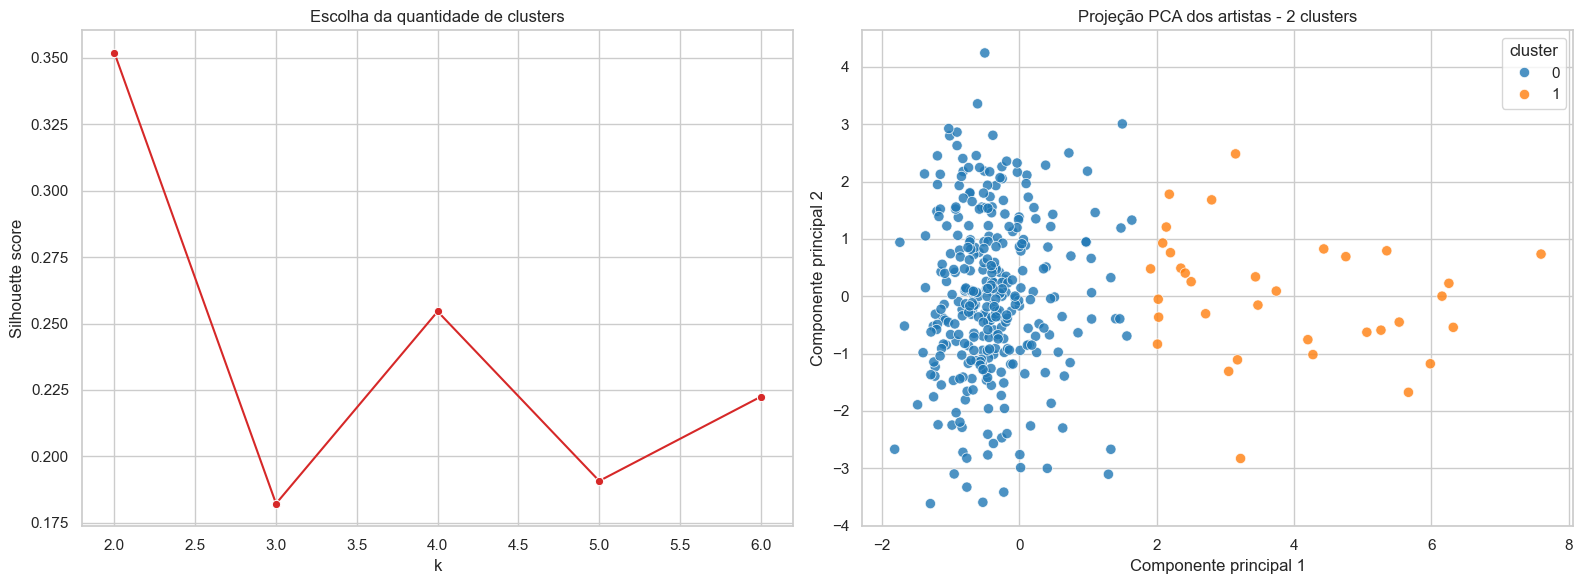

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=avaliacao_clusters, x="k", y="silhouette", marker="o", ax=axes[0], color="#D62828")
axes[0].set(title="Escolha da quantidade de clusters", ylabel="Silhouette score")

sns.scatterplot(data=cluster_df, x="pca_1", y="pca_2", hue="cluster", palette="tab10", s=55, alpha=.8, ax=axes[1])
axes[1].set(title=f"Projeção PCA dos artistas - {melhor_k} clusters", xlabel="Componente principal 1", ylabel="Componente principal 2")

plt.tight_layout()
plt.show()

In [12]:
perfil_clusters = cluster_df.groupby("cluster").agg(
    artistas=("artist_id", "count"),
    mediana_posts=("posts_count", "median"),
    mediana_imagens=("img_count", "median"),
    mediana_seguindo=("following_count", "median"),
    percentual_website=("possui_website", "mean"),
    percentual_business=("is_business", "mean"),
    mediana_seguidores=("follower_count", "median"),
).round(2)

perfil_clusters[["percentual_website", "percentual_business"]] *= 100
perfil_clusters

,artistas,mediana_posts,mediana_imagens,mediana_seguindo,percentual_website,percentual_business,mediana_seguidores
cluster,,,,,,,
0,325,52.0,20.0,387.0,43.0,22.153846,301.0
1,34,57.0,24.0,413.0,100.0,8.823529,316.0


**Como interpretar:** os clusters descrevem perfis semelhantes nas features selecionadas. Eles podem ajudar a pensar em jornadas e recomendações diferentes, mas não representam estilos artísticos, amizades ou níveis de qualidade. O `silhouette score` deve ser usado para verificar se a separação encontrada é minimamente consistente.

## Principais insights do contempArt

1. Instagram é frequente, enquanto website independente aparece em pouco mais da metade dos registros.
2. As métricas digitais são fortemente assimétricas e exigem medianas, percentis e escalas logarítmicas.
3. Volume de publicações possui relação com seguidores, mas não explica sozinho a visibilidade.
4. Existem 82 artistas com volume de imagens acima da mediana e seguidores abaixo da mediana.
5. Os 10% maiores perfis concentram cerca de 44,6% dos seguidores.
6. A taxa de engajamento relativo tende a cair conforme seguidores e publicações aumentam.
7. Agrupamentos por características permitem conhecer perfis digitais distintos sem transformar popularidade em ranking.

## Como esta análise responde ao FlowCarreiras

| Achado analisado | Decisão ou hipótese para o FlowCarreiras |
| --- | --- |
| Muitos artistas possuem Instagram, mas não website | Oferecer portfólio público próprio e compartilhável |
| Popularidade é fortemente assimétrica | Evitar ordenar descoberta somente por seguidores |
| Volume registrado não explica sozinho a visibilidade | Combinar recência, áreas, tags e diversidade de exposição |
| Existem perfis com volume alto e visibilidade baixa | Garantir espaço de descoberta para artistas pouco alcançados externamente |
| Website e seguidores representam dimensões diferentes | Separar organização profissional de popularidade |
| Clusters apresentam perfis digitais distintos | Pensar em recomendações e jornadas diferentes, sem criar ranking de qualidade |

Assim, o contempArt não é analisado apenas para descrever artistas alemães. Ele funciona como evidência externa para testar escolhas do FlowCarreiras relacionadas a portfólio independente e exposição justa. As conclusões não comprovam impacto do aplicativo e devem ser validadas futuramente com dados reais de uso.